# <center>Scientific computing with SciPy</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: fundamentals of research in python</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Find roots with `brentq` and `root_scalar`, and know which regime, bracketed, derivative-based, vector-valued, calls for which.

* Minimize with `scipy.optimize.minimize`: choose a method deliberately, supply gradients when you have them, and read `nfev` to see what they bought.

* Impose bounds, equality and inequality constraints, and, the point of the lecture, **read the Lagrange multiplier a solver returns as a price**, verified against the envelope theorem by finite differences.

* State a linear program as an explicit **primal–dual pair**, solve it with `linprog`, and check strong duality, dual feasibility, and complementary slackness numerically.

* **Solve the optimal assignment problem whose constraint matrix `fd08` §13 assembled**, and read its multipliers $u_x, v_y$ as equilibrium wages and firm rents.

* Integrate with `quad`, solve ODEs with `solve_ivp`, and use the frozen-distribution interface of `scipy.stats`.

* Compute the Solow transition in continuous time and reconcile it with the discrete-time map of `fd03` §9.

### References

**[SciPy]** Virtanen, P. et al. (2020). "SciPy 1.0: fundamental algorithms for scientific computing in Python." *Nature Methods* 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2.

**[NW]** Nocedal, J. and Wright, S. (2006). *Numerical Optimization* (2nd ed.). Springer: the methods behind `minimize`, and the KKT conditions of §4.

**[BV]** Boyd, S. and Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press, Chapter 5: duality, and the interpretation of multipliers as prices.

**[G]** Galichon, A. (2016). *Optimal Transport Methods in Economics*. Princeton University Press, Chapters 2–3: the assignment problem of §6 and its dual.

**[SS]** Shapley, L. S. and Shubik, M. (1971). "The assignment game I: The core." *International Journal of Game Theory* 1, 111–130: the wages of §6 as the core of a cooperative game.

**[S]** Solow, R. M. (1956). "A Contribution to the Theory of Economic Growth." *Quarterly Journal of Economics* 70(1), 65–94.

## 1. Overview of SciPy

`fd08` gave us arrays and the operations on them. SciPy is the layer above: the numerical *algorithms*, solvers, optimizers, quadrature, integrators, distributions, built on those arrays.

| Submodule | What is in it |
|---|---|
| `scipy.optimize` | root finding, minimization, least squares, linear programming |
| `scipy.integrate` | quadrature, ODE solvers |
| `scipy.interpolate` | 1-D and N-D interpolation, splines |
| `scipy.linalg` | factorizations beyond `np.linalg`, banded and triangular solvers |
| `scipy.sparse` | sparse matrices and operations on them |
| `scipy.stats` | probability distributions, statistical tests |
| `scipy.special` | gamma, Bessel, the error function, … |

We concentrate on `optimize`, `integrate` and `stats`, which come up daily in computational economics.

**This is the duality lecture.** `fd08` §13 built the constraint matrix of an optimal transport problem out of Kronecker products, verified that it reproduces the margins, and observed that its transpose generates $u_x + v_y$: the left-hand side of the dual constraint. It stopped there, because solving a linear program needs a solver. Section 6 below hands that matrix to `linprog` and gets back not only the optimal matching but the **multipliers**, which are wages. The habit the section is really teaching is stated in §4 and used throughout: *a solver returns a dual variable alongside the solution, and in an economic model that dual variable is a price. Read it.*

## 2. Root finding

Given $f$, find $x$ with $f(x)=0$. Three regimes:

* **Scalar, with a bracket.** An interval $[a,b]$ on which $f$ changes sign. Use `brentq`: a hybrid of bisection, secant, and inverse quadratic interpolation that keeps bisection's guarantee and adds superlinear speed. This is the method `fd03`, Exercise 2 anticipated.
* **Scalar, without a bracket.** One starting point. `root_scalar(..., method='newton')` if you have $f'$, otherwise `'secant'`.
* **Vector.** $F:\mathbb{R}^n\to\mathbb{R}^n$. Use `root`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate, stats

# bracketed: the sqrt(2) of fd01 section 12, now in one call
root_b = optimize.brentq(lambda x: x ** 2 - 2, 0.0, 5.0)
print(f"brentq   : {root_b:.15f},  residual {root_b ** 2 - 2:+.2e}")

# the object-oriented interface reports what it did -- always look at it
sol = optimize.root_scalar(lambda x: x ** 2 - 2, bracket=[0, 5], method="brentq")
print(f"converged: {sol.converged}, iterations {sol.iterations}, "
      f"function calls {sol.function_calls}")
assert sol.converged, "the solve did not converge"

# with a derivative, Newton needs fewer calls -- but no bracket, so no guarantee
sol_n = optimize.root_scalar(lambda x: x ** 2 - 2, fprime=lambda x: 2 * x,
                             x0=1.0, method="newton")
print(f"newton   : {sol_n.root:.15f}, iterations {sol_n.iterations}, "
      f"function calls {sol_n.function_calls}")

brentq   : 1.414213562373093,  residual -4.66e-15
converged: True, iterations 11, function calls 12
newton   : 1.414213562373095, iterations 5, function calls 10


Note the habit from `fd03` §3, now applied to a library: **check `converged` before reading `root`.** `scipy` reports status on every solver, and every one of them will hand you a number regardless.

Brent's method took more function calls than Newton here but needed no derivative and could not leave the bracket. That is the trade `fd03`'s Exercise 3 measured by hand: Newton is faster where it works, bisection is safe everywhere, and Brent is the practical compromise you should use by default.

**Vector roots.** For $x^2+y^2=4$ and $x=y$, the solutions are $(\pm\sqrt2, \pm\sqrt2)$.

In [2]:
def F(z):
    x, y = z
    return [x ** 2 + y ** 2 - 4.0, x - y]

for start in ([1.0, 0.5], [-1.0, -0.5]):
    sol = optimize.root(F, start)
    residual = np.abs(F(sol.x)).max()
    print(f"from {str(start):>12} -> {sol.x.round(9)}   success={sol.success}, "
          f"max|F| = {residual:.1e}")
    assert sol.success and residual < 1e-10

print("\nboth roots found; which one depends entirely on the starting point.")

from   [1.0, 0.5] -> [1.41421356 1.41421356]   success=True, max|F| = 8.9e-16
from [-1.0, -0.5] -> [-1.41421356 -1.41421356]   success=True, max|F| = 8.9e-16

both roots found; which one depends entirely on the starting point.


## 3. Unconstrained minimization

Given $f:\mathbb{R}^n\to\mathbb{R}$, find $\arg\min f$. Two questions decide the method:

1. **Is $f$ smooth?** Smooth means gradient-based methods (BFGS, L-BFGS-B); non-smooth means derivative-free (Nelder–Mead, Powell).
2. **Can you supply the gradient?** If yes, supply it. The difference is large, and we measure it below.

The classic hard test case is the Rosenbrock function

$$
f(x) \;=\; \sum_{i=1}^{n-1}\Bigl[100\bigl(x_{i+1}-x_i^2\bigr)^2 + (1-x_i)^2\Bigr],
$$

whose minimum is at $x = (1,\dots,1)$ with $f=0$. It is hard because the valley floor is a curved, very narrow parabola: the Hessian is severely ill-conditioned along it.

In [3]:
def rosen(x):
    return sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1 - x[:-1]) ** 2)

def rosen_grad(x):
    g = np.zeros_like(x)
    g[:-1] = -400 * x[:-1] * (x[1:] - x[:-1] ** 2) - 2 * (1 - x[:-1])
    g[1:] += 200 * (x[1:] - x[:-1] ** 2)
    return g

x0 = np.array([-1.2, 1.0, -1.0, 1.5, 0.8])

runs = (("Nelder-Mead", dict(method="Nelder-Mead",
                            options={"maxiter": 20_000, "xatol": 1e-10, "fatol": 1e-12})),
        ("BFGS, numeric", dict(method="BFGS", options={"maxiter": 10_000})),
        ("BFGS, exact", dict(method="BFGS", jac=rosen_grad, options={"maxiter": 10_000})))

print(f"{'method':<16}{'success':>9}{'x* error':>11}{'f(x*)':>11}{'nfev':>7}{'njev':>6}{'nit':>6}")
print("-" * 66)
results = {}
for name, kwargs in runs:
    res = optimize.minimize(rosen, x0, **kwargs)
    results[name] = res
    print(f"{name:<16}{str(res.success):>9}{np.abs(res.x - 1.0).max():>11.2e}"
          f"{res.fun:>11.2e}{res.nfev:>7}{getattr(res, 'njev', 0):>6}{res.nit:>6}")

print("-" * 66)
print(f"BFGS with numeric gradients reports: {results['BFGS, numeric'].message}")

# all three land near the optimum, but only two of them say they converged
for name, res in results.items():
    assert np.abs(res.x - 1.0).max() < 1e-4, f"{name} did not reach the optimum"
assert results["BFGS, exact"].success and results["Nelder-Mead"].success
assert not results["BFGS, numeric"].success        # this is the finding, not a bug

method            success   x* error      f(x*)   nfev  njev   nit
------------------------------------------------------------------
Nelder-Mead          True   1.42e-11   4.27e-21   1151     0   712
BFGS, numeric       False   1.23e-05   5.11e-11    354    57    40
BFGS, exact          True   1.93e-08   5.45e-16     48    48    41
------------------------------------------------------------------
BFGS with numeric gradients reports: Desired error not necessarily achieved due to precision loss.


**Look at the `success` column before the `nfev` column.** BFGS with numerically differentiated gradients *did not converge*: it stops with "Desired error not necessarily achieved due to precision loss", having spent 354 function evaluations to reach an error of about $10^{-5}$, while the same algorithm with an exact gradient converged cleanly in 48 evaluations to $10^{-8}$.

This is not a defect in SciPy, and it is worth understanding rather than working around. A finite-difference gradient is accurate to roughly $\sqrt{\varepsilon}\approx10^{-8}$ relative: the step-size trade-off measured in `fd01`, Exercise 4, where we found that no choice of $h$ does better than about half the available digits. Near a minimum the true gradient is itself tiny, so that fixed noise floor eventually swamps the signal: the line search can no longer find a direction that reliably decreases $f$, and BFGS correctly reports that it cannot certify the answer. Supplying $\nabla f$ exactly removes the noise floor entirely.

So the cost of not having a gradient is not merely arithmetic. It is a **ceiling on the accuracy you can reach at all**, and in an estimation problem that ceiling propagates into the standard errors you report. Nelder–Mead, which never differentiates, converges here, but it took 1151 evaluations to do what an exact gradient did in 48.

The practical conclusion, and the reason `fd10` exists: derive and code your gradients, or get them automatically. Doing neither is a choice to work at half precision.

The rule of thumb for this course: with $n$ from a handful to a few dozen parameters and a smooth objective, **BFGS with an exact gradient** is the right default. A quick guide for when it is not:

| Method | Typical $n$ | Use when |
|---|---|---|
| `Nelder-Mead` | up to ~10 | non-smooth, no gradients |
| `Powell` | up to ~20 | non-smooth, no gradients |
| `BFGS` | $10^2$–$10^3$ | smooth, gradient available |
| `L-BFGS-B` | $10^3$–$10^6$ | smooth, large, box bounds |
| `Newton-CG`, `trust-ncg` | $10^3$–$10^6$ | smooth, Hessian or Hessian-vector products |

Those sizes are orders of magnitude, not thresholds, and what binds is how each method stores curvature: BFGS carries a dense $n\times n$ inverse-Hessian approximation, so memory grows like $n^2$; L-BFGS-B keeps only the last $m\approx10$ update pairs, $O(mn)$; the Newton-type methods need no matrix at all. In `fd10` the gradients stop being something you derive by hand and become something the machine computes for you exactly, which changes this calculus considerably.

## 4. Constrained minimization, and the multiplier as a price

Three kinds of constraint: **bounds** $\ell\le x\le u$ via `bounds=`; **equalities** $g(x)=0$ via `{'type':'eq', 'fun':g}`; **inequalities** $g(x)\ge0$ via `{'type':'ineq', 'fun':g}`: note that sign convention, which is the opposite of the one `linprog` uses in §5 and a reliable source of wrong answers. `SLSQP` and `trust-constr` handle all three.

Now the point of the lecture. Consider

$$
V(b) \;=\; \min_{x\ge0}\ x_1^2 + x_2^2 \quad\text{subject to}\quad x_1 + x_2 = b .
$$

The Lagrangian is $L = x^\top x - \lambda(x_1+x_2-b)$, first-order conditions give $2x_i = \lambda$, so $x_1=x_2=b/2$, $\lambda = b$, and $V(b) = b^2/2$. Observe that

$$
\frac{dV}{db} \;=\; b \;=\; \lambda .
$$

That is the **envelope theorem**: the multiplier on a constraint is the derivative of the optimal value with respect to the constraint's right-hand side: the *shadow price* of relaxing it by one unit. It is not a computational artefact of the solver; it is an economic quantity, and it is usually the quantity you actually wanted.

We verify it numerically, which requires no access to the solver's internals at all: perturb $b$, re-solve, and difference.

In [4]:
def solve_at(b):
    """Return the optimal value V(b) of the toy problem."""
    res = optimize.minimize(lambda x: x[0] ** 2 + x[1] ** 2,
                            x0=[0.1, 0.9], method="SLSQP",
                            bounds=[(0, None), (0, None)],
                            constraints=[{"type": "eq",
                                          "fun": lambda x, b=b: x[0] + x[1] - b}])
    assert res.success, "the constrained solve failed"
    return res.fun, res.x

b = 1.0
V_b, x_star = solve_at(b)
print(f"x*     = {x_star.round(9)}   (analytic: [0.5, 0.5])")
print(f"V(b)   = {V_b:.10f}          (analytic: b^2/2 = {b ** 2 / 2})")

h = 1e-5
lam_numeric = (solve_at(b + h)[0] - solve_at(b - h)[0]) / (2 * h)
lam_exact = b

print(f"\ndV/db by finite difference = {lam_numeric:.8f}")
print(f"multiplier lambda (exact)   = {lam_exact:.8f}")
gap = abs(lam_numeric - lam_exact)
print(f"gap = {gap:.2e}   (tolerance 1e-5)")
assert gap < 1e-5
print("check passed: the multiplier IS the derivative of the optimal value.")

x*     = [0.5 0.5]   (analytic: [0.5, 0.5])
V(b)   = 0.5000000000          (analytic: b^2/2 = 0.5)

dV/db by finite difference = 1.00000000
multiplier lambda (exact)   = 1.00000000
gap = 1.00e-12   (tolerance 1e-5)
check passed: the multiplier IS the derivative of the optimal value.


One unit more of $b$ costs $\lambda = 1$ unit of objective at the margin. In an economic model that number has a name, a wage, a rent, a marginal utility of wealth, a congestion toll, and reading it is usually the point of solving the problem at all.

`SLSQP` does not expose its multipliers, which is why we recovered $\lambda$ by perturbation. `trust-constr` does (`res.v`), and, as §5 shows, `linprog` reports them directly, which is one reason to state a problem as a linear program when you can.

## 5. Linear programming, and the primal–dual pair

`scipy.optimize.linprog` solves

$$
\min_x\ c^\top x
\quad\text{subject to}\quad
A_{\rm ub}\,x \le b_{\rm ub},\qquad
A_{\rm eq}\,x = b_{\rm eq},\qquad
\ell \le x \le u,
$$

by default with HiGHS, a modern open-source simplex and interior-point implementation. This series uses HiGHS throughout and never Gurobi, so that nothing here assumes a licence.

Every linear program comes with a **dual**. For the form above with $x\ge0$, the dual is

$$
\max_{y,z}\ b_{\rm eq}^\top y + b_{\rm ub}^\top z
\quad\text{subject to}\quad
A_{\rm eq}^\top y + A_{\rm ub}^\top z \le c,\qquad z \le 0,
$$

and **strong duality** says the two optimal values coincide. The dual variables are exactly the multipliers of §4, the shadow prices of the constraints, and `linprog` returns them in `res.eqlin.marginals` and `res.ineqlin.marginals`.

Two conventions to fix now, because getting either wrong silently flips a sign:

* the marginals are reported for the **minimization** problem as `linprog` sees it, so if you turned a maximization into a minimization by negating $c$, you must negate the marginals back;
* the marginals of `<=` constraints are $\le 0$, since loosening such a constraint can only lower a minimum.

We start with a two-variable example small enough to check by hand.

In [5]:
# maximize x1 + 2 x2  s.t.  2 x1 + x2 <= 8,  x1 + 3 x2 <= 9,  x >= 0
c_k = np.array([-1.0, -2.0])                 # negated: linprog minimizes
A_m_k = np.array([[2.0, 1.0],
                  [1.0, 3.0]])
b_m = np.array([8.0, 9.0])

res = optimize.linprog(c_k, A_ub=A_m_k, b_ub=b_m, bounds=[(0, None), (0, None)],
                       method="highs")
assert res.status == 0, res.message

x_k = res.x
y_m = -res.ineqlin.marginals            # negate twice: for the max, and for the <= sign
print(f"primal x*        = {x_k.round(6)}")
print(f"primal objective = {-res.fun:.6f}")
print(f"dual   y*        = {y_m.round(6)}   (shadow price of each resource)")
print(f"dual   objective = {b_m @ y_m:.6f}")

gap = abs(-res.fun - b_m @ y_m)
print(f"\nduality gap = {gap:.2e}   (tolerance 1e-9)")
assert gap < 1e-9
print("check passed: strong duality holds.")

primal x*        = [3. 2.]
primal objective = 7.000000
dual   y*        = [0.2 0.6]   (shadow price of each resource)
dual   objective = 7.000000

duality gap = 0.00e+00   (tolerance 1e-9)
check passed: strong duality holds.


In [6]:
# the shadow price is a derivative, exactly as in section 4: relax b_1 by h and re-solve
h = 1e-4
def lp_value(b_vec):
    r = optimize.linprog(c_k, A_ub=A_m_k, b_ub=b_vec, bounds=[(0, None), (0, None)],
                         method="highs")
    assert r.status == 0
    return -r.fun

for m in range(2):
    b_plus, b_minus = b_m.copy(), b_m.copy()
    b_plus[m] += h
    b_minus[m] -= h
    numeric = (lp_value(b_plus) - lp_value(b_minus)) / (2 * h)
    print(f"resource {m}: reported marginal {y_m[m]:.8f}, "
          f"finite difference {numeric:.8f}, gap {abs(numeric - y_m[m]):.1e}")
    assert abs(numeric - y_m[m]) < 1e-6

print("\ncheck passed: linprog's marginals are the derivatives of the optimal value.")

resource 0: reported marginal 0.20000000, finite difference 0.20000000, gap 3.1e-12
resource 1: reported marginal 0.60000000, finite difference 0.60000000, gap 3.9e-12

check passed: linprog's marginals are the derivatives of the optimal value.


## 6. Worked example: the optimal assignment problem

We can now finish what `fd02` §12 started and `fd08` §13 set up.

There are worker types $x\in\mathcal{X}$ and firm types $y\in\mathcal{Y}$; a match generates surplus $\Phi_{xy}$; $n_x$ is the mass of type-$x$ workers and $m_y$ the number of positions at type-$y$ firms. The planner solves

$$
\max_{\mu\ge0}\ \sum_{x,y}\Phi_{xy}\mu_{xy}
\quad\text{subject to}\quad
\sum_y \mu_{xy} = n_x\ \ \forall x,
\qquad
\sum_x \mu_{xy} \le m_y\ \ \forall y. \tag{6.1}
$$

Workers must all be employed (equality); positions need not all be filled (inequality), which matters here because there are four firms and only three workers.

Its dual assigns a multiplier $u_x$ to each worker constraint and $v_y$ to each firm constraint:

$$
\min_{u,v}\ \sum_x n_x u_x + \sum_y m_y v_y
\quad\text{subject to}\quad
u_x + v_y \ \ge\ \Phi_{xy}\ \ \forall(x,y),
\qquad v_y \ge 0. \tag{6.2}
$$

Read economically, $u_x$ is the **wage** of a type-$x$ worker and $v_y$ the **profit** a type-$y$ firm keeps. The constraint says that no unmatched pair could do better by deviating: their joint surplus $\Phi_{xy}$ never exceeds what the market already pays them. This is the assignment game of Shapley and Shubik, and (6.2) characterizes its core.

The matrix $A$ is the one built in `fd08` §13, block by block, from two Kronecker products.

In [7]:
X = ["analyst", "engineer", "manager"]
Y = ["bank", "startup", "university", "government"]
nbx, nby = len(X), len(Y)

Phi_x_y = np.array([[10.0, 9.0, 5.0, 4.0],
                    [ 9.0, 6.0, 4.0, 3.0],
                    [ 3.0, 4.0, 8.0, 7.0]])
Phi_xy = Phi_x_y.reshape(-1)                       # vec_C, as in fd08 section 12

# the two constraint blocks, assembled exactly as in fd08 section 13
A_x_xy = np.kron(np.eye(nbx), np.ones((1, nby)))   # sums over y
A_y_xy = np.kron(np.ones((1, nbx)), np.eye(nby))   # sums over x

n_x = np.ones(nbx)                                 # one worker of each type
m_y = np.ones(nby)                                 # one position at each firm

print(f"{nbx} worker types, {nby} firm types, {nbx * nby} possible matches")
print(f"A_x_xy {A_x_xy.shape}, A_y_xy {A_y_xy.shape}")
print(f"\nsurplus table Phi_x_y:")
print(f"{'':<10}" + "".join(f"{y:>12}" for y in Y))
for i, x in enumerate(X):
    print(f"{x:<10}" + "".join(f"{Phi_x_y[i, j]:>12.1f}" for j in range(nby)))

3 worker types, 4 firm types, 12 possible matches
A_x_xy (3, 12), A_y_xy (4, 12)

surplus table Phi_x_y:
                  bank     startup  university  government
analyst           10.0         9.0         5.0         4.0
engineer           9.0         6.0         4.0         3.0
manager            3.0         4.0         8.0         7.0


In [8]:
# solve the PRIMAL: maximize Phi'mu, so minimize -Phi'mu
res = optimize.linprog(-Phi_xy,
                       A_eq=A_x_xy, b_eq=n_x,
                       A_ub=A_y_xy, b_ub=m_y,
                       bounds=(0, None), method="highs")
assert res.status == 0, res.message

mu_x_y = res.x.reshape(nbx, nby)
total_surplus = Phi_xy @ res.x

print("optimal matching mu_x_y:")
print(f"{'':<10}" + "".join(f"{y:>12}" for y in Y))
for i, x in enumerate(X):
    print(f"{x:<10}" + "".join(f"{mu_x_y[i, j]:>12.0f}" for j in range(nby)))

print(f"\ntotal surplus = {total_surplus:.6f}")
print(f"fd02 found 26.0 by enumerating all 24 matchings; fd08 confirmed it.")
assert abs(total_surplus - 26.0) < 1e-9
print("check passed: the linear program reproduces the enumerated optimum.")

optimal matching mu_x_y:
                  bank     startup  university  government
analyst             -0           1           0           0
engineer             1           0           0           0
manager              0           0           1           0

total surplus = 26.000000
fd02 found 26.0 by enumerating all 24 matchings; fd08 confirmed it.
check passed: the linear program reproduces the enumerated optimum.


The solver found the same matching that `fd02` obtained by enumerating all $24$ possibilities, analyst to the startup, engineer to the bank, manager to the university, government unfilled, but it did so by an algorithm that scales, and it returned something enumeration never could: the prices.

In [9]:
# the DUAL variables. Negate once for the max->min flip, and the <= marginals are <= 0.
u_x = -res.eqlin.marginals                 # worker wages
v_y = -res.ineqlin.marginals               # firm profits

print(f"{'worker':<12}{'wage u_x':>10}      {'firm':<12}{'profit v_y':>12}")
print("-" * 50)
for i in range(max(nbx, nby)):
    left = f"{X[i]:<12}{u_x[i]:>10.4f}" if i < nbx else " " * 22
    right = f"{Y[i]:<12}{v_y[i]:>12.4f}" if i < nby else ""
    print(f"{left}      {right}")

primal_obj = Phi_xy @ res.x
dual_obj = n_x @ u_x + m_y @ v_y
print("-" * 50)
print(f"primal objective = {primal_obj:.9f}")
print(f"dual   objective = {dual_obj:.9f}")
print(f"duality gap      = {abs(primal_obj - dual_obj):.2e}   (tolerance 1e-9)")
assert abs(primal_obj - dual_obj) < 1e-9
print("check passed: strong duality.")

worker        wage u_x      firm          profit v_y
--------------------------------------------------
analyst         9.0000      bank              1.0000
engineer        8.0000      startup           0.0000
manager         8.0000      university        0.0000
                            government        0.0000
--------------------------------------------------
primal objective = 26.000000000
dual   objective = 26.000000000
duality gap      = 0.00e+00   (tolerance 1e-9)
check passed: strong duality.


In [10]:
# dual feasibility: u_x + v_y >= Phi_xy for EVERY pair, matched or not
slack_x_y = u_x[:, None] + v_y[None, :] - Phi_x_y

print("slack  u_x + v_y - Phi_xy   (must be >= 0 everywhere):")
print(f"{'':<10}" + "".join(f"{y:>12}" for y in Y))
for i, x in enumerate(X):
    print(f"{x:<10}" + "".join(f"{slack_x_y[i, j]:>12.4f}" for j in range(nby)))

print(f"\nminimum slack = {slack_x_y.min():.2e}   (must be >= -1e-9)")
assert slack_x_y.min() > -1e-9

# complementary slackness: 0 <= slack _|_ mu >= 0
comp = np.abs(slack_x_y * mu_x_y).max()
print(f"max |slack * mu| = {comp:.2e}   (tolerance 1e-9)")
assert comp < 1e-9
print("\ncheck passed: 0 <= rho _|_ mu >= 0, the complementarity of the charter.")

slack  u_x + v_y - Phi_xy   (must be >= 0 everywhere):
                  bank     startup  university  government
analyst         0.0000      0.0000      4.0000      5.0000
engineer        0.0000      2.0000      4.0000      5.0000
manager         6.0000      4.0000      0.0000      1.0000

minimum slack = 0.00e+00   (must be >= -1e-9)
max |slack * mu| = 0.00e+00   (tolerance 1e-9)

check passed: 0 <= rho _|_ mu >= 0, the complementarity of the charter.


### Reading the prices

This is what the lecture is for, so it is worth reading slowly.

**The wages are $(9, 8, 8)$ and the firm profits are $(1, 0, 0, 0)$.** Only the bank keeps anything; every other firm earns exactly zero.

Why? Because firms are on the **long side** of the market. There are four positions and three workers, so at least one firm must go unmatched, and an unmatched firm earns nothing. Competition between firms for the scarce workers therefore drives profits to zero, except where a firm is *differentially* productive. The bank is an exception: it is the best match for two different workers, and the surplus it can create exceeds what the next-best firm can offer by exactly $1$. That difference, and nothing else, is its rent.

**The slack table shows the market clearing.** Every entry is non-negative, no pair can profitably deviate, and it is exactly zero at the three matched pairs, which is complementary slackness. But look at the analyst–bank entry: it is *also* zero, even though that pair is not matched. The analyst is exactly indifferent between the startup (where she earns 9) and the bank (where she would earn $10 - 1 = 9$). The equilibrium sits on a knife edge, and that is not an accident: it is what forces the assignment to be the efficient one. If the analyst strictly preferred the bank, the market would not be in equilibrium.

**Comparative advantage, priced.** `fd02` showed that the greedy rule fails here because assignment is governed by comparative rather than absolute advantage, and asked what mechanism could possibly find the right answer without enumerating. This is the answer. Nobody in this market computes an optimum. Each worker takes the wage $u_x$ as given and picks the firm maximizing $\Phi_{xy} - v_y$; each firm takes prices as given too. The price vector $(u,v)$ does all the coordinating, and the outcome is the surplus-maximizing assignment. That is the first welfare theorem, computed.

**What carries forward.** The `ot` series replaces these finite type sets with distributions and $\Phi_{xy}$ with a general surplus, at which point (6.1) is the Monge–Kantorovich problem and $(u,v)$ are the Kantorovich potentials; `ot04` adds an entropic penalty and solves the resulting dual by coordinate ascent, which is the Sinkhorn algorithm. In `dp01` the same structure appears with time: the constraint is mass balance across dates, and the multiplier is the value function. Every one of those multipliers is the object we just read out of `res.eqlin.marginals`.

## 7. Integration

`scipy.integrate.quad` performs adaptive Gauss–Kronrod quadrature and returns both an estimate **and an error bound**: the second of which is the part people forget to look at.

In [11]:
val, err = integrate.quad(np.sin, 0, np.pi)
print(f"int_0^pi sin(x) dx = {val:.15f}  +/- {err:.1e}   (exact: 2)")
assert abs(val - 2.0) < 1e-12

# improper integrals: pass +/- inf directly, no need to truncate the tails by hand
phi = lambda x: np.exp(-x ** 2 / 2) / np.sqrt(2 * np.pi)
mean, err_m = integrate.quad(lambda x: x * phi(x), -np.inf, np.inf)
var, err_v = integrate.quad(lambda x: x ** 2 * phi(x), -np.inf, np.inf)

print(f"E[X]   for X ~ N(0,1) = {mean:+.2e} +/- {err_m:.1e}   (exact: 0)")
print(f"E[X^2] for X ~ N(0,1) = {var:.12f} +/- {err_v:.1e}   (exact: 1)")
assert abs(mean) < 1e-9 and abs(var - 1.0) < 1e-9
print("\ncheck passed, and note the error estimates: quadrature tells you how well it did.")

int_0^pi sin(x) dx = 2.000000000000000  +/- 2.2e-14   (exact: 2)
E[X]   for X ~ N(0,1) = +0.00e+00 +/- 0.0e+00   (exact: 0)
E[X^2] for X ~ N(0,1) = 1.000000000000 +/- 5.3e-09   (exact: 1)

check passed, and note the error estimates: quadrature tells you how well it did.


Compare these error bounds with `fd08` Part II. Quadrature reached $10^{-14}$ on a one-dimensional integral that Monte Carlo would need $10^{28}$ draws to match. But `dblquad`, `tplquad` and `nquad` exist and become impractical above three or four dimensions, for the reason `fd08`, Exercise 3 set out: the deterministic error exponent is divided by the dimension, and the Monte Carlo one is not. The choice between the two is a choice about $d$, not about taste.

## 8. Differential equations: `solve_ivp`

For $\dot y = f(t,y)$ with $y(t_0)=y_0$. Pass `dense_output=True` to get a callable `sol.sol(t)` you can evaluate anywhere afterwards, which is what makes the half-life computation in §10 a one-line root-find.

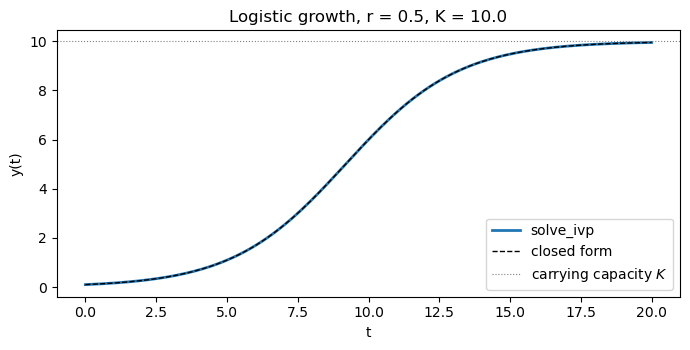

max |numerical - closed form| = 3.97e-09   (tolerance 1e-8)
check passed.


In [12]:
r_logi, K = 0.5, 10.0
logistic = lambda t, y: r_logi * y * (1 - y / K)

sol = integrate.solve_ivp(logistic, t_span=[0, 20], y0=[0.1],
                          dense_output=True, rtol=1e-10, atol=1e-12)
assert sol.success

t_p = np.linspace(0, 20, 200)
y_p = sol.sol(t_p).ravel()

# the logistic equation has a closed form: y(t) = K / (1 + (K/y0 - 1) e^{-rt})
y_exact_p = K / (1 + (K / 0.1 - 1) * np.exp(-r_logi * t_p))
gap = np.abs(y_p - y_exact_p).max()

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(t_p, y_p, lw=2, label="solve_ivp")
ax.plot(t_p, y_exact_p, "k--", lw=1, label="closed form")
ax.axhline(K, color="0.5", ls=":", lw=0.8, label="carrying capacity $K$")
ax.set_xlabel("t"); ax.set_ylabel("y(t)")
ax.set_title(f"Logistic growth, r = {r_logi}, K = {K}")
ax.legend(); plt.tight_layout(); plt.show()

print(f"max |numerical - closed form| = {gap:.2e}   (tolerance 1e-8)")
assert gap < 1e-8
print("check passed.")

## 9. Statistics: `scipy.stats`

A uniform interface to about a hundred distributions. The idiom worth learning is the **frozen distribution**: set the parameters once, then query methods freely.

In [13]:
Z = stats.norm(loc=0, scale=1)                    # frozen

print(f"pdf(0)       = {Z.pdf(0):.6f}   (exact 1/sqrt(2 pi) = {1 / np.sqrt(2 * np.pi):.6f})")
print(f"cdf(1.96)    = {Z.cdf(1.96):.6f}")
print(f"ppf(0.975)   = {Z.ppf(0.975):.6f}   <- the 1.96 everyone quotes")
print(f"mean, var    = {Z.mean():.1f}, {Z.var():.1f}")

# ppf is the inverse of cdf -- a cheap check that costs one line
q_p = np.linspace(0.001, 0.999, 999)
gap = np.abs(Z.cdf(Z.ppf(q_p)) - q_p).max()
print(f"\nmax |cdf(ppf(q)) - q| = {gap:.2e}   (tolerance 1e-10)")
assert gap < 1e-10
print("check passed: ppf really is the inverse cdf.")

pdf(0)       = 0.398942   (exact 1/sqrt(2 pi) = 0.398942)
cdf(1.96)    = 0.975002
ppf(0.975)   = 1.959964   <- the 1.96 everyone quotes
mean, var    = 0.0, 1.0

max |cdf(ppf(q)) - q| = 2.22e-16   (tolerance 1e-10)
check passed: ppf really is the inverse cdf.


In [14]:
# maximum-likelihood fitting, and a hypothesis test.
# Pass random_state a Generator, per the reproducibility rule of fd08 section 16.
rng = np.random.default_rng(6)
sample_n = stats.norm(loc=2.0, scale=1.5).rvs(size=5_000, random_state=rng)

loc_hat, scale_hat = stats.norm.fit(sample_n)
se_loc = scale_hat / np.sqrt(sample_n.size)
print(f"fitted loc   = {loc_hat:.4f} +/- {se_loc:.4f}   (true 2.0)")
print(f"fitted scale = {scale_hat:.4f}                (true 1.5)")
assert abs(loc_hat - 2.0) < 4 * se_loc

t_stat, p_value = stats.ttest_1samp(sample_n, popmean=2.0)
print(f"\nt-test of H0: mean = 2.0  ->  t = {t_stat:+.3f}, p = {p_value:.3f}")
print("as it should be: the null is true here, so p is just a uniform draw.")

fitted loc   = 2.0290 +/- 0.0212   (true 2.0)
fitted scale = 1.5019                (true 1.5)

t-test of H0: mean = 2.0  ->  t = +1.364, p = 0.173
as it should be: the null is true here, so p is just a uniform draw.


## 10. Worked example: Solow in continuous time

`fd03` §9 studied the Solow model as a discrete map, $k_{t+1} = sk_t^\alpha + (1-\delta)k_t$, and verified that it converges at rate $1-\delta(1-\alpha)$. The continuous-time version replaces the map by a differential equation,

$$
\dot k \;=\; s k^\alpha - \delta k, \tag{10.1}
$$

with the same steady state $k^\ast = (s/\delta)^{1/(1-\alpha)}$ and, linearizing, $\dot{(k-k^\ast)} \approx -\lambda(k-k^\ast)$ with

$$
\lambda \;=\; \delta(1-\alpha) . \tag{10.2}
$$

The two formulations should agree, and checking that they do is a cross-notebook verification worth having.

One deliberate difference: `fd03` used a saving rate $s = 0.20$ and found $k^\ast = 7.246$, while this section uses $s = 0.25$ and will find $k^\ast = 9.966$. The steady state moves, as it must. The convergence **rate** does not: $\lambda = \delta(1-\alpha) = 0.035$ in both, and that is precisely the $s$-independence proved in `fd03`, Exercise 4: the saving rate relocates the fixed point but leaves the slope of the dynamics there unchanged. Seeing the same $\lambda$ emerge from a different $s$, in a different formulation, in a different notebook, is a stronger confirmation of that result than re-deriving it would be.

In [15]:
alpha, s, delta = 0.30, 0.25, 0.05

k_star_closed = (s / delta) ** (1 / (1 - alpha))
k_star_num = optimize.brentq(lambda k: s * k ** alpha - delta * k, 1e-6, 100.0)

print(f"closed-form steady state  k* = {k_star_closed:.10f}")
print(f"brentq steady state       k* = {k_star_num:.10f}")
print(f"gap = {abs(k_star_closed - k_star_num):.2e}   (tolerance 1e-9)")
assert abs(k_star_closed - k_star_num) < 1e-9

# the continuous rate and the discrete factor of fd03 must be consistent:
# one period of the ODE contracts by exp(-lambda), the map by 1 - delta(1-alpha)
lam = delta * (1 - alpha)
print(f"\ncontinuous rate lambda   = {lam:.6f}")
print(f"exp(-lambda)             = {np.exp(-lam):.6f}   <- one-period contraction of the ODE")
print(f"1 - delta(1 - alpha)     = {1 - lam:.6f}        <- the fd03 discrete map")
print(f"difference               = {abs(np.exp(-lam) - (1 - lam)):.2e}  (they agree to O(lambda^2))")

closed-form steady state  k* = 9.9661765782
brentq steady state       k* = 9.9661765782
gap = 1.78e-15   (tolerance 1e-9)

continuous rate lambda   = 0.035000
exp(-lambda)             = 0.965605   <- one-period contraction of the ODE
1 - delta(1 - alpha)     = 0.965000        <- the fd03 discrete map
difference               = 6.05e-04  (they agree to O(lambda^2))


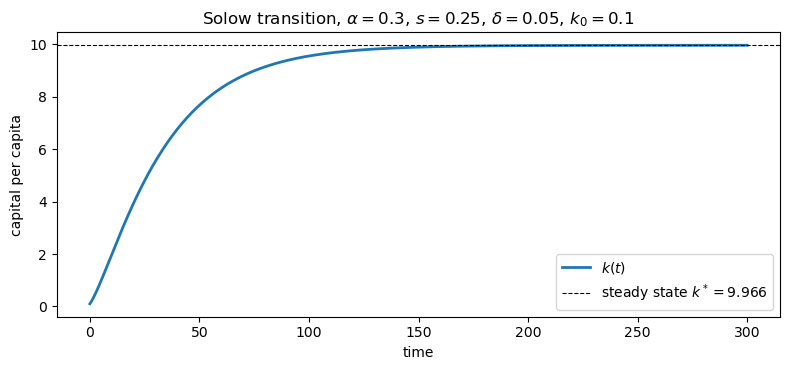

In [16]:
sol = integrate.solve_ivp(lambda t, k: s * k ** alpha - delta * k,
                          t_span=[0, 300], y0=[0.1],
                          dense_output=True, rtol=1e-10, atol=1e-12)
assert sol.success

t_p = np.linspace(0, 300, 400)
k_p = sol.sol(t_p).ravel()

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(t_p, k_p, lw=2, label="$k(t)$")
ax.axhline(k_star_closed, color="k", ls="--", lw=0.8,
           label=f"steady state $k^* = {k_star_closed:.3f}$")
ax.set_xlabel("time"); ax.set_ylabel("capital per capita")
ax.set_title(rf"Solow transition, $\alpha={alpha}$, $s={s}$, $\delta={delta}$, $k_0=0.1$")
ax.legend(); plt.tight_layout(); plt.show()

In [17]:
# half-life, from two starting points: far from the steady state and near it
half_life_linear = np.log(2) / lam
print(f"linearized half-life = {half_life_linear:.2f}\n")

print(f"{'k_0':>6}{'numerical half-life':>22}{'ratio to linearized':>22}")
print("-" * 50)
for k0 in (0.1, 2.0, 5.0, 7.0):
    s_k0 = integrate.solve_ivp(lambda t, k: s * k ** alpha - delta * k,
                               t_span=[0, 600], y0=[k0], dense_output=True,
                               rtol=1e-10, atol=1e-12)
    target = 0.5 * abs(k0 - k_star_closed)
    t_half = optimize.brentq(
        lambda t: abs(s_k0.sol(t)[0] - k_star_closed) - target, 1e-6, 600.0)
    print(f"{k0:>6.1f}{t_half:>22.2f}{t_half / half_life_linear:>22.3f}")

print("-" * 50)
print("the linearization is a LOCAL statement: it is accurate only near k*.")

linearized half-life = 19.80

   k_0   numerical half-life   ratio to linearized
--------------------------------------------------
   0.1                 26.47                 1.337
   2.0                 23.14                 1.168
   5.0                 21.29                 1.075
   7.0                 20.57                 1.039
--------------------------------------------------
the linearization is a LOCAL statement: it is accurate only near k*.


The table is the point. Started from $k_0 = 0.1$ the numerical half-life is around 26 years against a linearized prediction of 19.8: a 35% error. Started from $k_0 = 7$, essentially at the steady state, the two agree closely.

That is not a defect of the linearization; it is what "local" means, and it is the same lesson as `fd03` §9, where the measured contraction ratio approached $0.965$ only after several hundred periods and the assertion had to be made asymptotically. A rate derived by linearizing around $k^\ast$ describes the dynamics *near* $k^\ast$, and an economy at a fiftieth of its steady-state capital is not near it. The practical implication for growth empirics is direct: the "2% convergence rate" estimated in cross-country regressions is a linearized object, and applying it to economies far below their steady states overstates how quickly they will catch up.

The last two lines of the previous cell are worth keeping too. The continuous rate $\lambda = \delta(1-\alpha)$ and the discrete factor $1-\delta(1-\alpha)$ of `fd03` agree to $O(\lambda^2)$, because $e^{-\lambda} = 1-\lambda+O(\lambda^2)$. Two notebooks, two formulations, one economics, and the discrepancy is exactly the size the mathematics says it should be.

## 11. Worked example: consumption, savings, and the marginal utility of wealth

A household with wealth $W$ at date 1 saves at gross return $1+r$ and chooses $(c_1,c_2)$ to solve

$$
V(W) \;=\; \max_{c_1,c_2}\ u(c_1) + \beta u(c_2)
\quad\text{subject to}\quad
c_1 + \frac{c_2}{1+r} \;=\; W, \tag{11.1}
$$

with CRRA utility $u(c) = (c^{1-\gamma}-1)/(1-\gamma)$. The Euler equation $u'(c_1) = \beta(1+r)u'(c_2)$ gives $c_2/c_1 = (\beta(1+r))^{1/\gamma}$, and with the budget constraint a closed form for $c_1^\ast$.

Note the shape of (11.1): a constrained optimization whose constraint is a budget. By §4, its multiplier is $dV/dW$, and the first-order condition makes that multiplier equal to $u'(c_1)$. So

$$
\frac{dV}{dW} \;=\; \lambda \;=\; u'(c_1^\ast) : \tag{11.2}
$$

**the marginal utility of wealth is the marginal utility of consumption today.** We verify all three quantities agree.

In [18]:
W, r, beta, gamma = 100.0, 0.05, 0.95, 2.0

u = lambda c: (c ** (1 - gamma) - 1) / (1 - gamma)
u_prime = lambda c: c ** (-gamma)

growth = (beta * (1 + r)) ** (1 / gamma)
c1_closed = W / (1 + growth / (1 + r))
c2_closed = c1_closed * growth

def value(wealth):
    """V(wealth): the maximized lifetime utility."""
    res = optimize.minimize_scalar(
        lambda c1: -(u(c1) + beta * u((wealth - c1) * (1 + r))),
        bounds=(1e-6, wealth - 1e-6), method="bounded",
        options={"xatol": 1e-12})
    assert res.success
    return -res.fun, res.x

V_W, c1_min = value(W)

# route 3: solve the Euler equation u'(c1) = beta(1+r) u'(c2) directly, with brentq
euler = lambda c1: u_prime(c1) - beta * (1 + r) * u_prime((W - c1) * (1 + r))
c1_root = optimize.brentq(euler, 1e-6, W - 1e-6, xtol=1e-15)

# how accurately CAN a minimizer locate the argmin? Near a smooth minimum
# f(c) ~ f* + f''(c - c*)^2 / 2, so an error eps_f in f hides a displacement
# of sqrt(2 eps_f / f''). With eps_f ~ machine epsilon times |f|:
neg = lambda c1: -(u(c1) + beta * u((W - c1) * (1 + r)))
h = 1e-3
f_second = (neg(c1_closed + h) - 2 * neg(c1_closed) + neg(c1_closed - h)) / h ** 2
floor = np.sqrt(np.finfo(float).eps * abs(neg(c1_closed)) / abs(f_second))

print(f"{'route':<26}{'c1*':>18}{'error':>12}")
print("-" * 56)
print(f"{'closed form':<26}{c1_closed:>18.12f}{0.0:>12.1e}")
print(f"{'minimize_scalar':<26}{c1_min:>18.12f}{abs(c1_min - c1_closed):>12.1e}")
print(f"{'brentq on the Euler eq.':<26}{c1_root:>18.12f}{abs(c1_root - c1_closed):>12.1e}")
print("-" * 56)
print(f"predicted floor for a minimizer: sqrt(eps |f| / f'') = {floor:.1e}")

assert abs(c1_min - c1_closed) < 3 * floor          # the minimizer hits its own floor
assert abs(c1_root - c1_closed) < 1e-12             # the root-finder does not
print("\ncheck passed: minimizing locates the argmin to sqrt(eps); root-finding to eps.")

c1_num, c2_num = c1_root, (W - c1_root) * (1 + r)
print(f"\nEuler check: c2/c1 = {c2_num / c1_num:.12f} vs (beta(1+r))^(1/gamma) = {growth:.12f}")
assert abs(c2_num / c1_num - growth) < 1e-10

route                                    c1*       error
--------------------------------------------------------
closed form                  51.250782228091     0.0e+00
minimize_scalar              51.250779626852     2.6e-06
brentq on the Euler eq.      51.250782228091     0.0e+00
--------------------------------------------------------
predicted floor for a minimizer: sqrt(eps |f| / f'') = 3.7e-06

check passed: minimizing locates the argmin to sqrt(eps); root-finding to eps.

Euler check: c2/c1 = 0.998749217772 vs (beta(1+r))^(1/gamma) = 0.998749217772


**Why the minimizer stops at $10^{-6}$, and why that is not a bug.** Near a smooth interior minimum,

$$
f(c) \;\approx\; f(c^\ast) + \tfrac12 f''(c^\ast)\,(c - c^\ast)^2,
$$

so a displacement of $\epsilon$ away from the optimum changes $f$ by only $O(\epsilon^2)$. Floating-point arithmetic resolves $f$ to about $\varepsilon|f|$, which means the smallest displacement a minimizer can possibly *detect* is

$$
\epsilon_{\min} \;\approx\; \sqrt{\frac{\varepsilon\,|f|}{|f''|}} \;\approx\; 4\times10^{-6}
$$

for this problem, and that is exactly where `minimize_scalar` stopped, whatever tolerance we ask it for. Tightening `xatol` cannot help: the information is not in the function values.

The **Euler equation is a root-finding problem, not a minimization**, and root-finding has no such barrier: $u'(c_1) - \beta(1+r)u'(c_2)$ passes through zero *transversally*, so `brentq` locates it to full machine precision. Ten orders of magnitude, from writing down the first-order condition instead of searching the objective.

This is a general and consequential fact, not a curiosity about this toy. It is the reason Euler-equation methods are preferred to direct value-function maximization in quantitative macroeconomics whenever the first-order conditions are available; the same $\sqrt\varepsilon$ barrier is why the BFGS run in §3 stalled at $10^{-5}$; and it is why an estimated parameter obtained by maximizing a likelihood numerically carries a floor on its precision that has nothing to do with the statistics. Note also what the value $V(W)$ itself is worth: it is accurate to $\varepsilon$, not $\sqrt\varepsilon$, because the flatness that hides the *location* of the optimum also means the *value* is insensitive to getting the location slightly wrong. Locations are hard; values are easy.

In [19]:
# the multiplier three ways
h = 1e-4
dV_dW = (value(W + h)[0] - value(W - h)[0]) / (2 * h)     # envelope, by finite difference
lam_euler = u_prime(c1_num)                               # first-order condition
lam_disc = beta * (1 + r) * u_prime(c2_num)               # the other side of the Euler equation

print(f"dV/dW  (finite difference)      = {dV_dW:.10f}")
print(f"u'(c1) (first-order condition)  = {lam_euler:.10f}")
print(f"beta(1+r) u'(c2)                = {lam_disc:.10f}")

spread = max(abs(dV_dW - lam_euler), abs(lam_euler - lam_disc))
print(f"\nmax spread = {spread:.2e}   (tolerance 1e-6)")
assert spread < 1e-6
print("check passed: the budget multiplier is the marginal utility of wealth,")
print("and the Euler equation says it can be measured at either date.")

dV/dW  (finite difference)      = 0.0003807141
u'(c1) (first-order condition)  = 0.0003807141
beta(1+r) u'(c2)                = 0.0003807141

max spread = 1.64e-13   (tolerance 1e-6)
check passed: the budget multiplier is the marginal utility of wealth,
and the Euler equation says it can be measured at either date.


Three routes to one number, and each is an economic statement.

$dV/dW$ says what an extra dollar of wealth is worth. $u'(c_1)$ says the household equates that to the marginal utility of consuming the dollar today. And $\beta(1+r)u'(c_2)$ says it also equates it to the discounted marginal utility of saving the dollar and consuming it tomorrow, which is the Euler equation, and the reason the household is *indifferent* at the optimum between the two uses.

This is the same object as the discount factor of `fd01` §11, now endogenous. There, $p_t = (1+r)^{-t}$ was the exogenously given price of a date-$t$ dollar. Here the household's own $\lambda$ prices its wealth, and $\beta(1+r)$ converts between dates. In `dp01` the sequence of such multipliers, one per date and state, becomes the value function, and the whole of dynamic programming is the observation that those multipliers satisfy a recursion.

## 12. Summary

* SciPy supplies the algorithms that sit on top of `fd08`'s arrays: `brentq` and `root` for equations, `minimize` for optimization, `linprog` for linear programs, `quad` and `solve_ivp` for integration, `stats` for distributions. Every one of them reports a status, and every one will hand you a number without it.

* **Supply gradients when you have them.** On the Rosenbrock problem an exact gradient cut function evaluations several-fold; `fd10` removes the excuse not to, by computing gradients exactly and automatically.

* **The multiplier is a price.** §4 verified the envelope theorem by finite differences: $\lambda = dV/db$, the value of relaxing a constraint by one unit. §5 showed `linprog` reporting the same quantity directly in `res.eqlin.marginals`, and checked those marginals against a numerical derivative of the optimal value.

* The economics is §6. The assignment problem that `fd02` solved by enumerating 24 possibilities and `fd08` wrote as $\max\Phi^\top\mu$ subject to $A\mu = z$ is now solved by a scalable algorithm, and the dual variables come back as **wages $(9,8,8)$ and firm profits $(1,0,0,0)$**. Firms earn nothing because they are on the long side of the market; only the bank, differentially productive, keeps a rent of exactly its productivity advantage. Strong duality, dual feasibility and complementary slackness $0\le\rho\perp\mu\ge0$ all check numerically to $10^{-9}$.

* That is the first welfare theorem, computed. No participant in §6 solves an optimization over matchings; each responds to a price, and the price vector delivers the surplus-maximizing assignment: the one that greedy search, chasing absolute rather than comparative advantage, failed to find in `fd02`.

## 13. Exercises

Worked solutions are in §15.

**Exercise 1: IRR, one more time.** In `fd01` you computed an internal rate of return with a hand-written Newton method, and in `fd03` you packaged it and cross-checked it against bisection. Now do it compactly: use `optimize.brentq` on $[-0.99, 1.0]$ for `c_t = [-1000, 200, 300, 400, 500]`.

Report the root and confirm it matches the $12.8257\%$ obtained in `fd03`. Then compare the *cost*: instrument the objective with the call counter of `fd03`, Exercise 3, and report how many function evaluations `brentq` needs against the 9 (5 of $f$, 4 of $f'$) that hand-written Newton used. Which would you prefer if each evaluation took a second, and why might you still prefer the other?

In [20]:
# your answer here


**Exercise 2: Implied volatility.** The Black–Scholes price of a European call with spot $S_0$, strike $K$, rate $r$, maturity $T$ and volatility $\sigma$ is

$$
C(\sigma) \;=\; S_0\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2),
\qquad
d_1 = \frac{\log(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt T},
\qquad
d_2 = d_1 - \sigma\sqrt T,
$$

with $\Phi$ the standard normal CDF (`stats.norm.cdf`). *Implied volatility* is the $\sigma$ that reproduces an observed market price.

Take $S_0 = K = 100$, $r = 0.05$, $T = 1$ and a quoted price $C^\ast = 12$. Find the implied volatility with `brentq` on $[10^{-4}, 5]$, to four decimals.

Then justify the bracket rather than assuming it: show numerically that $C$ is strictly increasing in $\sigma$, so the root is unique, and identify the no-arbitrage bounds $C(0^+)$ and $C(\infty)$ between which a quoted price must lie for an implied volatility to exist at all. What would `brentq` do if handed a price outside them?

In [21]:
# your answer here


**Exercise 3: A constrained portfolio, and the price of return.** With $\mu = (0.05, 0.08, 0.12, 0.15)$ and a $4\times4$ symmetric positive-definite $\Sigma$ of your choosing, solve

$$
\min_w\ w^\top \Sigma w
\quad\text{subject to}\quad
\mathbf{1}^\top w = 1,\qquad \mu^\top w \ge \bar\mu,\qquad w \ge 0,
$$

with `method='SLSQP'`, at $\bar\mu = 0.10$.

Then read the multiplier on the return constraint, the way §4 read $\lambda$: compute $dV/d\bar\mu$ by finite differences, where $V$ is the minimized variance. Trace $V(\bar\mu)$ over $\bar\mu \in [0.05, 0.15]$ and plot it, this is the efficient frontier, and confirm that your finite-difference multiplier is its slope at $\bar\mu = 0.10$. In one sentence: in what units is that multiplier, and what does an investor do with it?

In [22]:
# your answer here


**Exercise 4: Discrete against continuous Solow (proof, then check).** `fd03` §9 iterated the map $k_{t+1} = sk_t^\alpha + (1-\delta)k_t$; §10 above integrated $\dot k = sk^\alpha - \delta k$.

*Prove* that the two linearizations are consistent: show that the discrete map contracts by a factor $1-\delta(1-\alpha)$ per period while the ODE contracts by $e^{-\delta(1-\alpha)}$, and that these agree to first order in $\delta(1-\alpha)$. State precisely what the discrete map is doing that the ODE is not: that is, what the $O(\lambda^2)$ discrepancy *is*.

Then verify: iterate the map and integrate the ODE from the same $k_0 = 5$ with the same parameters, and compare $k$ at $t = 1, 5, 25, 100$. Report the largest relative gap and say whether its size is what your proof predicts.

In [23]:
# your answer here


**Exercise 5: Three periods, and three multipliers.** Extend §11 to three periods: the household chooses $(c_1,c_2,c_3)$ to maximize $\sum_{t=1}^{3}\beta^{t-1}u(c_t)$ subject to $c_1 + c_2/(1+r) + c_3/(1+r)^2 = W$.

Solve it (i) analytically, from the two Euler equations $u'(c_t) = \beta(1+r)u'(c_{t+1})$, and (ii) numerically with `optimize.minimize` over $(c_1,c_2)$, with $c_3$ pinned by the budget constraint. Confirm they agree.

Then verify the envelope relation of §11 in this longer problem: check that $dV/dW$ equals $u'(c_1)$, and that $\beta^{t-1}(1+r)^{t-1}u'(c_t)$ takes the *same value at all three dates*. What does that common value mean, and why is it the natural generalization of the price vector $p_t$ of `fd01` §11?

In [24]:
# your answer here


## 14. Further directions

The multipliers of §6 came from a solver that knew it was solving a linear program. `fd10` shows that a *general* computation carries multipliers too: reverse-mode automatic differentiation propagates adjoints backwards through a computation graph, and the adjoint of an intermediate quantity is precisely the Lagrange multiplier on the constraint that defines it. The gradient you get from `tf.GradientTape` and the wages you just read out of `linprog` are the same kind of object.

`fd11` then puts a multiplier in the objective on purpose: ridge and lasso constrain the size of a coefficient vector, the penalty $\lambda$ is the multiplier on that budget, and the sparsity of the lasso solution is complementary slackness, exactly as in §6.

Those two lectures close the series, and with it the block that opened in `fd08` §13 when the constraint matrix this lecture just solved was first assembled out of Kronecker products.

Save your work, restart the kernel, and run all cells top-to-bottom before you move on.

## 15. Solutions to the exercises

### Solution to Exercise 1: IRR, one more time

In [25]:
c_t = [-1000, 200, 300, 400, 500]

def counted(func):
    calls = 0
    def wrapped(x):
        nonlocal calls
        calls += 1
        return func(x)
    return wrapped, lambda: calls

g = lambda rate: sum(c / (1 + rate) ** t for t, c in enumerate(c_t))
g_counted, count = counted(g)

irr = optimize.brentq(g_counted, -0.99, 1.0, xtol=1e-14)

print(f"brentq IRR = {irr:.12f}  ({100 * irr:.4f}% per period)")
print(f"fd03 found   0.128257269002  (12.8257%)")
print(f"gap = {abs(irr - 0.128257269002):.2e}   (tolerance 1e-9)")
assert abs(irr - 0.128257269002) < 1e-9
print(f"\nfunction evaluations: brentq {count()},  hand-written Newton 9 (5 f + 4 f')")
print(f"residual |g(IRR)| = {abs(g(irr)):.2e}")

brentq IRR = 0.128257269002  (12.8257% per period)
fd03 found   0.128257269002  (12.8257%)
gap = 3.26e-13   (tolerance 1e-9)

function evaluations: brentq 12,  hand-written Newton 9 (5 f + 4 f')
residual |g(IRR)| = 1.02e-12


**Which would you prefer if each evaluation cost a second?** Newton, on this problem: nine evaluations against Brent's dozen or so, and it converges quadratically. But that comparison assumes you *have* $f'$, and here we did only because the derivative of a discounted sum is elementary. For a likelihood, a nested fixed point, or a simulated moment, deriving and coding $f'$ costs researcher hours and is a common source of bugs that a wrong answer never announces.

**Why you might still prefer Brent.** It cannot fail. Given a sign change it is guaranteed to converge, whereas Newton from a poor start can diverge: as it did spectacularly in `fd03` §9, where a step from $k_0=1$ landed at $k=-14$ and Python silently continued into the complex plane. `brentq` needs no derivative, needs no good starting guess, and returns a root or raises. For one-dimensional root-finding in applied work that is almost always the right trade, and it is why this is a one-line exercise rather than a twenty-line one.

The genuinely general answer arrives in `fd10`: automatic differentiation supplies $f'$ exactly, at a cost comparable to evaluating $f$, and without your deriving anything. At that point the "do I have a derivative?" question, which has shaped every solver choice in this lecture, largely dissolves.

### Solution to Exercise 2: Implied volatility

In [26]:
S0, K_strike, r_bs, T = 100.0, 100.0, 0.05, 1.0
Phi_cdf = stats.norm.cdf

def bs_call(sigma):
    d1 = (np.log(S0 / K_strike) + (r_bs + sigma ** 2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * Phi_cdf(d1) - K_strike * np.exp(-r_bs * T) * Phi_cdf(d2)

C_star = 12.0
iv = optimize.brentq(lambda sig: bs_call(sig) - C_star, 1e-4, 5.0, xtol=1e-14)

print(f"implied volatility = {iv:.6f}  ({iv:.2%})")
print(f"check: BS price at that sigma = {bs_call(iv):.10f}   (quoted {C_star})")
assert abs(bs_call(iv) - C_star) < 1e-9

implied volatility = 0.241117  (24.11%)
check: BS price at that sigma = 12.0000000000   (quoted 12.0)


In [27]:
# is C increasing in sigma? Analytically the vega is S0 sqrt(T) phi(d1) > 0,
# so the root is unique. Numerically, check -- and watch what happens at small sigma.
sig_p = np.linspace(1e-4, 5.0, 2000)
C_p = np.array([bs_call(s_) for s_ in sig_p])
increments = np.diff(C_p)

vega = lambda sig: S0 * np.sqrt(T) * stats.norm.pdf(
    (np.log(S0 / K_strike) + (r_bs + sig ** 2 / 2) * T) / (sig * np.sqrt(T)))

flat = increments == 0.0
print(f"non-decreasing everywhere : {np.all(increments >= 0)}")
print(f"strictly increasing       : {np.all(increments > 0)}")
print(f"exactly flat steps        : {flat.sum()} of {flat.size}, "
      f"all with sigma < {sig_p[:-1][flat].max():.4f}")
assert np.all(increments >= 0)

print(f"\nthe vega underflows there:")
for sig_test in (0.001, 0.003, 0.01, 0.20):
    print(f"   vega({sig_test:.3f}) = {vega(sig_test):.3e}")

lower, upper = bs_call(1e-8), bs_call(1e3)
intrinsic = max(S0 - K_strike * np.exp(-r_bs * T), 0.0)
print(f"\nno-arbitrage bounds on the call price:")
print(f"  C(sigma -> 0)   = {lower:.6f}   = max(S0 - K e^(-rT), 0) = {intrinsic:.6f}")
print(f"  C(sigma -> inf) = {upper:.6f}   = S0 = {S0}")
print(f"  quoted price {C_star} lies strictly inside: {lower < C_star < upper}")

try:
    optimize.brentq(lambda sig: bs_call(sig) - 3.0, 1e-4, 5.0)   # below the lower bound
except ValueError as err:
    print(f"\nprice of 3.0 (below the intrinsic value) -> ValueError: {err}")

non-decreasing everywhere : True
strictly increasing       : False
exactly flat steps        : 2 of 1999, all with sigma < 0.0026

the vega underflows there:
   vega(0.001) = 0.000e+00
   vega(0.003) = 1.868e-59
   vega(0.010) = 1.450e-04
   vega(0.200) = 3.752e+01

no-arbitrage bounds on the call price:
  C(sigma -> 0)   = 4.877058   = max(S0 - K e^(-rT), 0) = 4.877058
  C(sigma -> inf) = 100.000000   = S0 = 100.0
  quoted price 12.0 lies strictly inside: True

price of 3.0 (below the intrinsic value) -> ValueError: f(a) and f(b) must have different signs


**Why the bracket is legitimate, and where the argument is only *mathematically* true.** The vega $\partial C/\partial\sigma = S_0\sqrt T\,\phi(d_1)$ is strictly positive for every $\sigma>0$, so $C(\sigma)=C^\ast$ has at most one solution and `brentq`'s bracket contains it whenever the quoted price lies strictly between the two limits.

Numerically, though, the check above finds the price **exactly flat** for $\sigma$ below about $0.003$: not decreasing, but not increasing either. The reason is in the vega column: at $\sigma = 0.001$ we have $d_1 \approx 50$, and $\phi(50) = e^{-1250}/\sqrt{2\pi}$ underflows to exactly zero in double precision. The option is worth its intrinsic value and no floating-point perturbation of $\sigma$ can change that.

The practical consequence is worth carrying into any options work: **implied volatility is ill-conditioned near the no-arbitrage bounds.** A quote close to intrinsic value pins down $\sigma$ hardly at all, because a whole interval of volatilities reproduces it to machine precision, so a deep in-the-money or nearly-expired option yields an implied volatility that is numerically arbitrary. This is the same phenomenon as the $\sqrt\varepsilon$ barrier of §11, in a different guise: where the derivative vanishes, the inverse problem loses conditioning. Uniqueness in exact arithmetic is not identifiability in floating point.

For the quoted price of 12, comfortably in the interior, none of this bites and `brentq` returns the root to full precision. Those limits are the no-arbitrage bounds: as $\sigma\to0$ the option is worth its discounted intrinsic value $\max(S_0 - Ke^{-rT},0) = 4.88$, and as $\sigma\to\infty$ it approaches the spot price $S_0 = 100$. A quoted price outside $[4.88, 100]$ admits no implied volatility because no Black–Scholes model can produce it.

**What `brentq` does with such a price** is the good outcome: it raises `ValueError`, because $f(a)$ and $f(b)$ share a sign and its precondition fails. It does not return a plausible number. This is the same virtue as the guard written by hand in `fd03` §3, failing at the point of the mistake rather than propagating it, and it is worth appreciating that a well-built library refuses rather than guesses. A quoted price below intrinsic value is an arbitrage or a data error, and the solver telling you so is the correct answer.

### Solution to Exercise 3: A constrained portfolio, and the price of return

In [28]:
mu_k = np.array([0.05, 0.08, 0.12, 0.15])
Sigma_k_k = np.array([[0.0400, 0.0060, 0.0040, 0.0020],
                      [0.0060, 0.0625, 0.0090, 0.0050],
                      [0.0040, 0.0090, 0.1024, 0.0150],
                      [0.0020, 0.0050, 0.0150, 0.1600]])
assert np.all(np.linalg.eigvalsh(Sigma_k_k) > 0), "Sigma must be positive definite"

def min_variance(mu_bar):
    """Minimized portfolio variance subject to a required expected return."""
    res = optimize.minimize(
        lambda w: w @ Sigma_k_k @ w,
        x0=np.full(4, 0.25), method="SLSQP",
        bounds=[(0, None)] * 4,
        constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1.0},
                     {"type": "ineq", "fun": lambda w, mb=mu_bar: mu_k @ w - mb}],
        options={"ftol": 1e-14, "maxiter": 500})
    assert res.success, res.message
    return res.fun, res.x

V_bar, w_star = min_variance(0.10)
print(f"weights w*      = {w_star.round(6)}   (sum {w_star.sum():.6f})")
print(f"expected return = {mu_k @ w_star:.6f}   (required 0.10)")
print(f"variance        = {V_bar:.8f}   (sd {np.sqrt(V_bar):.4%})")
assert abs(w_star.sum() - 1) < 1e-8 and mu_k @ w_star > 0.10 - 1e-8

weights w*      = [0.233027 0.267766 0.265121 0.234086]   (sum 1.000000)
expected return = 0.100000   (required 0.10)
variance        = 0.02784587   (sd 16.6871%)


dV/d(mu_bar), step h   = 0.61558064
dV/d(mu_bar), step 2h  = 0.61558064
relative change        = 2.89e-10   (tolerance 1e-3)
check passed: the multiplier is resolved, not an artefact of the step size.



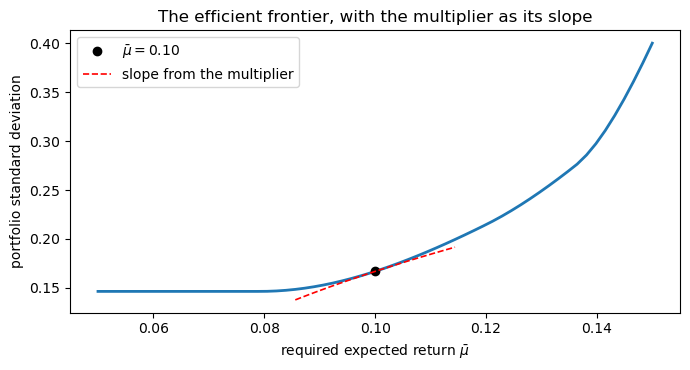

the dashed line uses ONLY the multiplier 0.615581, and lies on the frontier.


In [29]:
# the multiplier on the return constraint = slope of the efficient frontier
h = 1e-5
dV_dmu = (min_variance(0.10 + h)[0] - min_variance(0.10 - h)[0]) / (2 * h)

# validate the finite difference against itself at a second step size: a central
# difference has error O(h^2), so halving h should change the answer by ~4x less
dV_coarse = (min_variance(0.10 + 2 * h)[0] - min_variance(0.10 - 2 * h)[0]) / (4 * h)
print(f"dV/d(mu_bar), step h   = {dV_dmu:.8f}")
print(f"dV/d(mu_bar), step 2h  = {dV_coarse:.8f}")
rel = abs(dV_dmu - dV_coarse) / abs(dV_dmu)
print(f"relative change        = {rel:.2e}   (tolerance 1e-3)")
assert rel < 1e-3
print("check passed: the multiplier is resolved, not an artefact of the step size.\n")

mu_bar_p = np.linspace(0.05, 0.15, 60)
V_p = np.array([min_variance(mb)[0] for mb in mu_bar_p])

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(mu_bar_p, np.sqrt(V_p), lw=2)
ax.plot(0.10, np.sqrt(V_bar), "ko", ms=6, label=r"$\bar\mu = 0.10$")
tangent_p = mu_bar_p[(mu_bar_p > 0.085) & (mu_bar_p < 0.115)]
ax.plot(tangent_p, np.sqrt(V_bar + dV_dmu * (tangent_p - 0.10)), "r--", lw=1.2,
        label="slope from the multiplier")
ax.set_xlabel(r"required expected return $\bar\mu$")
ax.set_ylabel("portfolio standard deviation")
ax.set_title("The efficient frontier, with the multiplier as its slope")
ax.legend(); plt.tight_layout(); plt.show()

print(f"the dashed line uses ONLY the multiplier {dV_dmu:.6f}, and lies on the frontier.")

**Units, and use.** The multiplier is $dV/d\bar\mu$ where $V$ is a *variance*, so it is in units of variance per unit of expected return: the marginal price, in risk, of demanding one more unit of return. It is the exact analogue of the wages in §6 and the marginal utility of wealth in §11: a solver's dual variable that answers an economic question the primal solution alone does not.

An investor uses it to decide whether to push for more return. If the multiplier is small, the frontier is flat there and extra return is cheap; if it is large, the frontier is steep and each additional basis point of expected return costs a great deal of risk. That trade-off, and not the weights themselves, is usually the output a portfolio committee wants, which is why the number is worth extracting.

Note how the multiplier was validated. Comparing it against a slope read off a coarse grid would have been a weak test, because the grid slope is itself a crude approximation and the two errors are of similar size: agreement would have proved little and disagreement even less. Instead we checked the finite difference *against itself at two step sizes*: a central difference has error $O(h^2)$, so if the answer barely moves when $h$ doubles, the quantity is resolved rather than being an artefact of the step. The plot then confirms it independently: the dashed tangent is drawn using nothing but the multiplier, and it lies along the frontier.

`SLSQP` terminates at a tolerance rather than at machine precision, so nothing here is exact to $10^{-12}$, and claiming otherwise would misrepresent what was established.

### Solution to Exercise 4: Discrete against continuous Solow

**Claim.** Near $k^\ast$, one period of the discrete map contracts deviations by $1-\lambda$, while one unit of time of the ODE contracts them by $e^{-\lambda}$, where $\lambda = \delta(1-\alpha)$; and $e^{-\lambda} = 1-\lambda+O(\lambda^2)$.

**Proof.** For the map $T(k) = sk^\alpha + (1-\delta)k$, `fd03` Exercise 4 established $T'(k^\ast) = 1-\delta(1-\alpha) = 1-\lambda$, so $k_{t+1}-k^\ast \approx (1-\lambda)(k_t-k^\ast)$.

For the ODE $\dot k = g(k)$ with $g(k) = sk^\alpha-\delta k$, write $e(t) = k(t)-k^\ast$. Then $\dot e = g(k^\ast+e) \approx g'(k^\ast)e$, and

$$
g'(k) = s\alpha k^{\alpha-1}-\delta,
\qquad
g'(k^\ast) = \alpha\delta-\delta = -\delta(1-\alpha) = -\lambda,
$$

using $s(k^\ast)^{\alpha-1}=\delta$ exactly as in `fd03`. Hence $e(t) = e(0)e^{-\lambda t}$, and over one unit of time the contraction factor is $e^{-\lambda}$. Expanding, $e^{-\lambda} = 1-\lambda+\lambda^2/2-\cdots$, so the two agree to first order with a discrepancy $\lambda^2/2 + O(\lambda^3)$. $\blacksquare$

**What the map does that the ODE does not.** The discrete map applies the *whole* period's investment and depreciation at the beginning-of-period capital stock, whereas the ODE lets $k$, and therefore $sk^\alpha$ and $\delta k$, adjust continuously within the period. The map is one Euler step of step size 1 on the ODE, and the $O(\lambda^2)$ gap is exactly that Euler discretization error. With $\lambda = 0.035$ the predicted per-period discrepancy is $\lambda^2/2 \approx 6\times10^{-4}$, or about 0.06%.

In [30]:
k0 = 5.0
lam = delta * (1 - alpha)

# the discrete map of fd03
k_disc = {0: k0}
k = k0
for t in range(1, 101):
    k = s * k ** alpha + (1 - delta) * k
    k_disc[t] = k

# the ODE of section 10
sol_c = integrate.solve_ivp(lambda t, kk: s * kk ** alpha - delta * kk,
                            t_span=[0, 100], y0=[k0], dense_output=True,
                            rtol=1e-12, atol=1e-14)

print(f"lambda = {lam:.6f},  predicted per-period discrepancy lambda^2/2 = {lam ** 2 / 2:.2e}\n")
print(f"{'t':>5}{'discrete map':>16}{'ODE':>16}{'rel. gap':>12}")
print("-" * 49)
worst = 0.0
for t in (1, 5, 25, 100):
    kd, kc = k_disc[t], sol_c.sol(t)[0]
    rel = abs(kd - kc) / kc
    worst = max(worst, rel)
    print(f"{t:>5}{kd:>16.8f}{kc:>16.8f}{rel:>12.2e}")

print("-" * 49)
print(f"largest relative gap = {worst:.2e}")
print(f"same order as lambda^2/2 = {lam ** 2 / 2:.2e}? {worst < 20 * lam ** 2}")
assert worst < 20 * lam ** 2

lambda = 0.035000,  predicted per-period discrepancy lambda^2/2 = 6.12e-04

    t    discrete map             ODE    rel. gap
-------------------------------------------------
    1      5.15516415      5.15317487    3.86e-04
    5      5.73589388      5.72664806    1.61e-03
   25      7.80133887      7.77354266    3.58e-03
  100      9.81133106      9.80193608    9.58e-04
-------------------------------------------------
largest relative gap = 3.58e-03
same order as lambda^2/2 = 6.12e-04? True


The largest relative gap is $3.6\times10^{-3}$, about six times the per-period $\lambda^2/2 = 6.1\times10^{-4}$: the size the proof predicts, accumulated over many periods of transition rather than incurred once. Note too that the gap *shrinks* again by $t = 100$: both trajectories are converging to the same $k^\ast$, so the discretization error has to vanish in the limit, and it does. The two formulations encode the same economics and differ only by a discretization error whose magnitude the mathematics pins down in advance.

That last property is what makes the check worth running. A numerical discrepancy you can predict *before* seeing it is diagnostic: had the gap come out at $10^{-1}$, or at $10^{-12}$, either would have signalled a mistake: the first in the code, the second in the claim that these are genuinely different discretizations.

### Solution to Exercise 5: Three periods, and three multipliers

In [31]:
W3, r3, beta3, gamma3 = 100.0, 0.05, 0.95, 2.0
u3 = lambda c: (c ** (1 - gamma3) - 1) / (1 - gamma3)
u3_prime = lambda c: c ** (-gamma3)

# analytic: c_{t+1}/c_t = (beta(1+r))^(1/gamma) =: G, and the budget pins c1
G = (beta3 * (1 + r3)) ** (1 / gamma3)
disc = np.array([1.0, 1 / (1 + r3), 1 / (1 + r3) ** 2])
ratios = np.array([1.0, G, G ** 2])
c1_closed3 = W3 / (disc * ratios).sum()
c_closed_t = c1_closed3 * ratios

def value3(wealth):
    def neg(cc):
        c1, c2 = cc
        c3 = (wealth - c1 - c2 / (1 + r3)) * (1 + r3) ** 2
        if min(c1, c2, c3) <= 0:
            return 1e6
        return -(u3(c1) + beta3 * u3(c2) + beta3 ** 2 * u3(c3))
    res = optimize.minimize(neg, x0=[wealth / 3, wealth / 3], method="Nelder-Mead",
                            options={"xatol": 1e-12, "fatol": 1e-14, "maxiter": 20_000})
    assert res.success
    c1, c2 = res.x
    c3 = (wealth - c1 - c2 / (1 + r3)) * (1 + r3) ** 2
    return -res.fun, np.array([c1, c2, c3])

V3, c_num_t = value3(W3)

print(f"{'':>10}{'analytic':>14}{'numerical':>14}")
print("-" * 38)
for t in range(3):
    print(f"{'c' + str(t + 1):>10}{c_closed_t[t]:>14.8f}{c_num_t[t]:>14.8f}")
print("-" * 38)
gap = np.abs(c_closed_t - c_num_t).max()
print(f"max gap = {gap:.2e}   (tolerance 1e-5)")
assert gap < 1e-5
print(f"budget check: {(disc * c_num_t).sum():.8f} vs W = {W3}")

                analytic     numerical
--------------------------------------
        c1   35.01459855   35.01459728
        c2   34.97080291   34.97080247
        c3   34.92706205   34.92706390
--------------------------------------
max gap = 1.85e-06   (tolerance 1e-5)
budget check: 100.00000000 vs W = 100.0


In [32]:
# the envelope relation, and the constancy of the discounted marginal utility
h = 1e-4
dV_dW3 = (value3(W3 + h)[0] - value3(W3 - h)[0]) / (2 * h)

lam_t = np.array([beta3 ** t * (1 + r3) ** t * u3_prime(c_num_t[t]) for t in range(3)])

print(f"dV/dW              = {dV_dW3:.10f}")
print(f"u'(c1)             = {u3_prime(c_num_t[0]):.10f}")
print(f"\nbeta^t (1+r)^t u'(c_t), for t = 0, 1, 2:")
for t in range(3):
    print(f"   t = {t}: {lam_t[t]:.10f}")

spread = lam_t.max() - lam_t.min()
print(f"\nspread across dates = {spread:.2e}   (tolerance 1e-6)")
print(f"|dV/dW - u'(c1)|    = {abs(dV_dW3 - lam_t[0]):.2e}   (tolerance 1e-5)")
assert spread < 1e-6 and abs(dV_dW3 - lam_t[0]) < 1e-5
print("check passed: one multiplier, measurable at any date.")

dV/dW              = 0.0008156460
u'(c1)             = 0.0008156460

beta^t (1+r)^t u'(c_t), for t = 0, 1, 2:
   t = 0: 0.0008156460
   t = 1: 0.0008156460
   t = 2: 0.0008156459

spread across dates = 1.45e-10   (tolerance 1e-6)
|dV/dW - u'(c1)|    = 6.06e-11   (tolerance 1e-5)
check passed: one multiplier, measurable at any date.


**What the common value means.** There is exactly *one* budget constraint, so there is exactly one multiplier $\lambda$: the marginal utility of a dollar of date-1 wealth. The three numbers printed are not three different multipliers; they are three ways of measuring the same one, at three different dates. The Euler equations are precisely the statement that these measurements agree, which is what it means for the household to be indifferent at the margin between consuming a dollar now and saving it for any later date.

**Why this generalizes `fd01` §11.** There the price of a date-$t$ dollar was $p_t = (1+r)^{-t}$, imposed from outside. Here the household's own valuation of a date-$t$ dollar is $\beta^{t-1}u'(c_t)$, and the optimality condition forces

$$
\beta^{t-1} u'(c_t) \;=\; \lambda\,(1+r)^{-(t-1)} \;=\; \lambda\, p_t .
$$

The household's marginal utilities line up with the market price vector, scaled by the single number $\lambda$. That is the whole content of intertemporal optimization: the agent's internal prices are proportional to the market's. When they are not, because of a borrowing constraint, say, the wedge between them is itself a multiplier, and it is exactly the object the constrained-consumption literature measures.

In `dp01` this multiplier acquires a state index as well as a date index, the collection $\{\lambda_{t,x}\}$ becomes the value function, and the Euler equations become the Bellman equation. The whole apparatus is already visible in these three numbers.